# 🐍 Sesión 1 — De valores simples a una base Mincer con ENAHO

## 📊 Python para análisis de datos sociales

**Caso aplicado:** ¿cómo se relacionan descriptivamente la educación y el ingreso por hora de personas asalariadas en el Perú?

Trabajaremos con tres extractos reales de la ENAHO 2023: características de los miembros del hogar (200), educación (300) y empleo e ingresos (500). Primero aprenderemos Python con valores simples; desde el minuto 50 construiremos la base a nivel de persona.


## 🗺️ Ruta de la sesión (120 minutos)

| Minutos | Lo que haremos |
|---:|---|
| 0–50 | Sintaxis, tipos, operaciones, condiciones, listas, diccionarios y funciones. |
| 50–60 | Localizar e inspeccionar tres módulos ENAHO incluidos en la lección. |
| 60–87 | Construir el tamaño del hogar y unir las bases con claves. |
| 87–102 | Definir la muestra y crear variables para el caso Mincer. |
| 102–120 | Describir y visualizar los resultados. |

**Regla del curso:** cada transformación debe conservar la pregunta que responde, la unidad de observación y las variables que la justifican.


# 1. 🧩 Python con valores simples

En esta primera parte todavía no usamos una base. Usamos valores que se parecen a los que luego aparecerán en ENAHO. Cada celda puede ejecutarse con el botón ▶ o con `Shift + Enter`.


In [6]:
# Un valor se guarda con un nombre descriptivo.
edad = 35
anios_educacion = 16
ingreso_mensual = 4800.0
horas_semana = 0

print(edad)
print(ingreso_mensual)


35
4800.0


In [3]:
# type() permite ver el tipo de dato.
print(type(edad))
print(type(ingreso_mensual))
print(type('Perú'))
print(type(True))


<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


`int` representa enteros, `float` números con decimales, `str` texto y `bool` valores lógicos (`True` o `False`). Python distingue estos tipos porque no tiene sentido sumar un texto con un número sin una conversión explícita.


In [4]:
# Operaciones aritméticas.
semanas_por_mes = 4.33
ingreso_hora = ingreso_mensual / (horas_semana * semanas_por_mes)
experiencia_potencial = edad - anios_educacion - 6

print('Ingreso por hora:', round(ingreso_hora, 2))
print('Experiencia potencial:', experiencia_potencial)


Ingreso por hora: 23.09
Experiencia potencial: 13


In [7]:
# Una condición produce True o False.
tiene_datos_validos = ingreso_mensual > 0 and horas_semana > 0
print(tiene_datos_validos)

if tiene_datos_validos:
    print('Podemos calcular el ingreso por hora.')
else:
    print('Falta un ingreso u horas de trabajo positivos.')


False
Falta un ingreso u horas de trabajo positivos.


In [8]:
# Una lista guarda varios valores en un orden.
anios_educacion_grupo = [6, 11, 14, 16]

for anios in anios_educacion_grupo:
    print('Años de educación:', anios)


Años de educación: 6
Años de educación: 11
Años de educación: 14
Años de educación: 16


In [9]:
# Un diccionario vincula una etiqueta (clave) con un valor.
persona_ejemplo = {
    'sexo': 'Mujer',
    'edad': 32,
    'anios_educacion': 11,
    'ingreso_mensual': 1800.0
}

print(persona_ejemplo['sexo'])
print(persona_ejemplo['edad'])


Mujer
32


In [10]:
# Una función reúne una tarea que podremos reutilizar.
def calcular_experiencia_potencial(edad, anios_educacion):
    experiencia = edad - anios_educacion - 6
    return max(experiencia, 0)

def calcular_ingreso_hora(ingreso_mensual, horas_semana):
    if ingreso_mensual <= 0 or horas_semana <= 0:
        return None
    return ingreso_mensual / (horas_semana * 4.33)

print(calcular_experiencia_potencial(32, 11))
print(round(calcular_ingreso_hora(1800, 48), 2))


15
8.66


### ✍️ Pausa breve

Cambie los cuatro valores iniciales por los de una persona ficticia. Antes de ejecutar, anticipe: ¿su experiencia potencial será negativa?, ¿la función devolverá un número o `None`?


# 2. 📁 De módulos ENAHO a una base a nivel de persona

Ahora sí usamos datos. Los tres CSV ya están en la carpeta `data` de esta lección. Cada archivo es un módulo original reducido a los campos necesarios para la clase; **no es una base Mincer ya armada**. Conservaremos los módulos separados y crearemos una nueva tabla derivada.

| Archivo incluido | Unidad | Aporte al caso |
|---|---|---|
| `data/enaho_2023_200_clase.csv` | Persona | membresía, sexo, edad y estrato |
| `data/enaho_2023_300_clase.csv` | Persona de 3+ | nivel, año y grado educativo aprobados |
| `data/enaho_2023_500_clase.csv` | Persona de 14+ | empleo, categoría, horas, pago y factor |

Las claves de persona son `ano`, `conglome`, `vivienda`, `hogar` y `codperso`. Las cuatro primeras identifican el hogar; al añadir `codperso`, identificamos a una persona dentro de ese hogar.

Los extractos conservan todas las filas de los módulos oficiales ENAHO 2023 y solo seleccionan columnas. La carpeta `data` documenta las fuentes y los hashes de verificación.

In [11]:
# Librerías para trabajar con tablas y gráficos.
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')


In [12]:
# Los CSV viajan con la lección. Esta celda encuentra la carpeta tanto en Colab como localmente.
from pathlib import Path

NOMBRES_DATOS = [
    'enaho_2023_200_clase.csv',
    'enaho_2023_300_clase.csv',
    'enaho_2023_500_clase.csv',
]

def encontrar_carpeta_leccion():
    try:
        from google.colab import drive
        en_colab = True
    except ImportError:
        en_colab = False

    if en_colab:
        drive.mount('/content/drive')
        # Esta es la ubicación prevista después de copiar 01_python a Google Drive.
        carpeta = Path(
            '/content/drive/MyDrive/Courses/2026/Taught courses/'
            'Bootcamp data for social analysis/01_python'
        )
        if not carpeta.exists():
            raise FileNotFoundError(
                'No se encontró la lección en Google Drive. '
                'Revise la ruta marcada en esta celda si cambió el nombre o la ubicación de la carpeta.'
            )
        return carpeta

    # En Jupyter local funciona si se abre desde 01_python, notebooks o la carpeta del curso.
    for base in [Path.cwd(), *Path.cwd().parents]:
        for carpeta in (base, base / '01_python'):
            if all((carpeta / 'data' / nombre).exists() for nombre in NOMBRES_DATOS):
                return carpeta

    raise FileNotFoundError(
        'No se encontró la carpeta data con los tres CSV. '
        'Mantenga notebooks y data dentro de la misma carpeta 01_python.'
    )

CARPETA_LECCION = encontrar_carpeta_leccion()
RUTA_DATOS = CARPETA_LECCION / 'data'
print('Datos de la lección:', RUTA_DATOS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos de la lección: /content/drive/MyDrive/Courses/2026/Taught courses/Bootcamp data for social analysis/01_python/data


In [15]:
# Rutas completas a los tres extractos incluidos en la lección.
ARCHIVO_200 = RUTA_DATOS / 'enaho_2023_200_clase.csv'
ARCHIVO_300 = RUTA_DATOS / 'enaho_2023_300_clase.csv'
ARCHIVO_500 = RUTA_DATOS / 'enaho_2023_500_clase.csv'

archivos_esperados = [ARCHIVO_200, ARCHIVO_300, ARCHIVO_500]
faltantes = [str(archivo) for archivo in archivos_esperados if not archivo.exists()]
assert not faltantes, f'Faltan archivos: {faltantes}'

print('Archivos listos:')
for archivo in archivos_esperados:
    print('-', archivo.name)


Archivos listos:
- enaho_2023_200_clase.csv
- enaho_2023_300_clase.csv
- enaho_2023_500_clase.csv


In [16]:
# Normalizamos nombres: AÑO pasa a ano y todos los nombres quedan en minúsculas.
def normalizar_columna(nombre):
    nombre = unicodedata.normalize('NFD', nombre)
    nombre = ''.join(letra for letra in nombre if unicodedata.category(letra) != 'Mn')
    nombre = nombre.strip().lower().replace(' ', '_')
    return nombre

def leer_modulo(ruta):
    tabla = pd.read_csv(ruta, encoding='latin-1', low_memory=False, dtype=str)
    tabla.columns = [normalizar_columna(columna) for columna in tabla.columns]
    return tabla

modulo_200 = leer_modulo(ARCHIVO_200)
modulo_300 = leer_modulo(ARCHIVO_300)
modulo_500 = leer_modulo(ARCHIVO_500)


In [17]:
# Antes de transformar, inspeccionamos cada módulo.
for nombre, tabla in [('200', modulo_200), ('300', modulo_300), ('500', modulo_500)]:
    print(f'Módulo {nombre}: {tabla.shape[0]:,} filas y {tabla.shape[1]} columnas')
    print(list(tabla.columns))
    print()


Módulo 200: 119,747 filas y 10 columnas
['ano', 'conglome', 'vivienda', 'hogar', 'codperso', 'ubigeo', 'estrato', 'p204', 'p207', 'p208a']

Módulo 300: 108,354 filas y 8 columnas
['ano', 'conglome', 'vivienda', 'hogar', 'codperso', 'p301a', 'p301b', 'p301c']

Módulo 500: 86,654 filas y 11 columnas
['ano', 'conglome', 'vivienda', 'hogar', 'codperso', 'p501', 'p507', 'p513t', 'p523', 'p524a1', 'fac500a']



In [18]:
CLAVES_HOGAR = ['ano', 'conglome', 'vivienda', 'hogar']
CLAVES_PERSONA = CLAVES_HOGAR + ['codperso']

campos_200 = CLAVES_PERSONA + ['ubigeo', 'estrato', 'p204', 'p207', 'p208a']
campos_300 = CLAVES_PERSONA + ['p301a', 'p301b', 'p301c']
campos_500 = CLAVES_PERSONA + ['p501', 'p507', 'p513t', 'p523', 'p524a1', 'fac500a']

for nombre, tabla, campos in [
    ('200', modulo_200, campos_200),
    ('300', modulo_300, campos_300),
    ('500', modulo_500, campos_500)
]:
    faltantes = [campo for campo in campos if campo not in tabla.columns]
    assert not faltantes, f'Módulo {nombre}: faltan {faltantes}'

print('Los tres módulos contienen los campos requeridos.')


Los tres módulos contienen los campos requeridos.


## 🏠 Construir una variable del hogar

El módulo 200 contiene una fila por persona. La variable `p204` indica si la persona es miembro del hogar (`1 = Sí`). Al contar miembros por hogar creamos `tamano_hogar`, una variable a nivel de hogar que luego se repetirá para cada integrante del mismo hogar.


In [19]:
# Convertimos solo las columnas que son cantidades o códigos numéricos.
numericas_200 = ['estrato', 'p204', 'p207', 'p208a']
numericas_300 = ['p301a', 'p301b', 'p301c']
numericas_500 = ['p501', 'p507', 'p513t', 'p523', 'p524a1', 'fac500a']

for columna in numericas_200:
    modulo_200[columna] = pd.to_numeric(modulo_200[columna], errors='coerce')
for columna in numericas_300:
    modulo_300[columna] = pd.to_numeric(modulo_300[columna], errors='coerce')
for columna in numericas_500:
    modulo_500[columna] = pd.to_numeric(modulo_500[columna], errors='coerce')


In [20]:
# Conservamos únicamente miembros del hogar para el conteo.
miembros_hogar = modulo_200.loc[modulo_200['p204'] == 1, CLAVES_HOGAR].copy()

tamano_hogar = (
    miembros_hogar
    .groupby(CLAVES_HOGAR)
    .size()
    .reset_index(name='tamano_hogar')
)

tamano_hogar.head()


,ano,conglome,vivienda,hogar,tamano_hogar
0,2023,005007,022,11,3
1,2023,005007,031,11,1
2,2023,005027,006,11,5
3,2023,005027,018,11,4
4,2023,005027,044,11,5


In [21]:
# Revisamos el resultado antes de unirlo. Debe haber una sola fila por hogar.
duplicados_hogar = tamano_hogar.duplicated(CLAVES_HOGAR).sum()
print('Hogares con más de una fila:', duplicados_hogar)
print(tamano_hogar['tamano_hogar'].describe())
assert duplicados_hogar == 0


Hogares con más de una fila: 0
count    33886.000000
mean         3.300862
std          1.764451
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         22.000000
Name: tamano_hogar, dtype: float64


## 🎓 Educación y 💼 empleo

Para una primera aproximación didáctica convertimos el último nivel aprobado (`p301a`) a años aproximados de educación. Esta equivalencia es transparente pero simplificada: no reemplaza una construcción más fina con año y grado (`p301b`, `p301c`) ni una decisión metodológica documentada.


In [22]:
anios_por_nivel = {
    1: 0,   # Sin nivel
    2: 0,   # Inicial
    3: 3,   # Primaria incompleta: aproximación
    4: 6,   # Primaria completa
    5: 9,   # Secundaria incompleta: aproximación
    6: 11,  # Secundaria completa
    7: 13,  # Superior no universitaria incompleta: aproximación
    8: 14,  # Superior no universitaria completa: aproximación
    9: 14,  # Superior universitaria incompleta: aproximación
    10: 16, # Superior universitaria completa
    11: 18, # Maestría / doctorado: aproximación
    12: np.nan
}

educacion = modulo_300[CLAVES_PERSONA + ['p301a', 'p301b', 'p301c']].copy()
educacion['anios_educacion_aprox'] = educacion['p301a'].map(anios_por_nivel)

labor = modulo_500[CLAVES_PERSONA + ['p501', 'p507', 'p513t', 'p523', 'p524a1', 'fac500a']].copy()
labor.head()


,ano,conglome,vivienda,hogar,codperso,p501,p507,p513t,p523,p524a1,fac500a
0,2023,005030,002,11,01,1,4.0,28.0,4.0,1800.0,165.623856
1,2023,005030,002,11,02,1,2.0,78.0,NaN,NaN,112.328087
2,2023,005030,011,11,01,1,2.0,84.0,NaN,NaN,96.035370
3,2023,005030,011,11,02,1,5.0,84.0,NaN,NaN,86.868881
4,2023,005030,011,11,03,1,2.0,12.0,NaN,NaN,185.492355


In [23]:
educacion.head()

,ano,conglome,vivienda,hogar,codperso,p301a,p301b,p301c,anios_educacion_aprox
0,2023,005030,002,11,01,8,3.0,NaN,14.0
1,2023,005030,002,11,02,10,5.0,NaN,16.0
2,2023,005030,002,11,03,3,0.0,4.0,3.0
3,2023,005030,002,11,04,3,0.0,1.0,3.0
4,2023,005030,011,11,01,4,5.0,NaN,6.0


In [24]:
# p523 indica la frecuencia del pago; p524a1 es el monto del período anterior.
multiplicador_mensual = {1: 30, 2: 4.33, 3: 2, 4: 1}
labor['ingreso_mensual_nominal'] = labor['p524a1'] * labor['p523'].map(multiplicador_mensual)

labor[['p523', 'p524a1', 'ingreso_mensual_nominal']].head()


,p523,p524a1,ingreso_mensual_nominal
0,4.0,1800.0,1800.0
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


## 🔗 Unir sin perder el control

Nunca unimos tablas solo porque tienen el mismo número de filas. Primero verificamos que cada módulo tenga una sola fila por persona; después usamos `validate='one_to_one'`. Para el tamaño del hogar, muchas personas pueden pertenecer al mismo hogar, por eso el vínculo es `many_to_one`.


In [25]:
def revisar_clave(tabla, claves, nombre):
    duplicados = tabla.duplicated(claves).sum()
    print(f'{nombre}: {duplicados:,} filas duplicadas según la clave')
    assert duplicados == 0, f'Revisar duplicados en {nombre}'

personas = modulo_200[CLAVES_PERSONA + ['ubigeo', 'estrato', 'p204', 'p207', 'p208a']].copy()
revisar_clave(personas, CLAVES_PERSONA, 'Módulo 200')
revisar_clave(educacion, CLAVES_PERSONA, 'Módulo 300')
revisar_clave(labor, CLAVES_PERSONA, 'Módulo 500')


Módulo 200: 0 filas duplicadas según la clave
Módulo 300: 0 filas duplicadas según la clave
Módulo 500: 0 filas duplicadas según la clave


In [26]:
# Partimos de las personas del módulo 200 y agregamos información de los otros módulos.
base_persona = personas.merge(
    tamano_hogar,
    on=CLAVES_HOGAR,
    how='left',
    validate='many_to_one'
)

base_persona = base_persona.merge(
    educacion,
    on=CLAVES_PERSONA,
    how='left',
    validate='one_to_one',
    indicator='origen_educacion'
)

base_persona = base_persona.merge(
    labor,
    on=CLAVES_PERSONA,
    how='left',
    validate='one_to_one',
    indicator='origen_labor'
)

print('Filas de la base integrada:', len(base_persona))
print(base_persona[['origen_educacion', 'origen_labor']].value_counts())


Filas de la base integrada: 119747
origen_educacion  origen_labor
both              both            86654
                  left_only       21700
left_only         left_only       11393
Name: count, dtype: int64


In [27]:
# La integración mantuvo todas las personas de 200. Ahora identificamos campos faltantes.
campos_mincer = ['tamano_hogar', 'p208a', 'p207', 'anios_educacion_aprox',
                  'p501', 'p507', 'p513t', 'ingreso_mensual_nominal', 'fac500a']
base_persona[campos_mincer].isna().sum().sort_values(ascending=False)


,0
ingreso_mensual_nominal,94503
p513t,56160
p507,56160
fac500a,33093
p501,33093
anios_educacion_aprox,11605
p208a,3487
p207,3487
tamano_hogar,0


## 🎯 Definir la muestra y crear variables

Para este ejercicio descriptivo, la muestra es: miembros del hogar de 25 a 64 años, que trabajaron la semana anterior (`p501 = 1`), son asalariados (`p507` igual a 3, 4 o 6) y tienen ingreso mensual y horas positivas. Esta es una decisión didáctica explícita, no una definición universal de la población ocupada.


In [28]:
muestra = base_persona.copy()
pasos_muestra = []

pasos_muestra.append(['Base integrada', len(muestra)])
muestra = muestra.loc[muestra['p204'] == 1].copy()
pasos_muestra.append(['Miembros del hogar', len(muestra)])
muestra = muestra.loc[muestra['p208a'].between(25, 64)].copy()
pasos_muestra.append(['Edad de 25 a 64 años', len(muestra)])
muestra = muestra.loc[muestra['p501'] == 1].copy()
pasos_muestra.append(['Trabajó la semana anterior', len(muestra)])
muestra = muestra.loc[muestra['p507'].isin([3, 4, 6])].copy()
pasos_muestra.append(['Asalariados', len(muestra)])
muestra = muestra.loc[
    (muestra['ingreso_mensual_nominal'] > 0) & (muestra['p513t'] > 0)
].copy()
pasos_muestra.append(['Ingreso y horas positivos', len(muestra)])

pd.DataFrame(pasos_muestra, columns=['Paso', 'Personas'])


,Paso,Personas
0,Base integrada,119747
1,Miembros del hogar,111853
2,Edad de 25 a 64 años,52822
3,Trabajó la semana anterior,41519
4,Asalariados,18299
5,Ingreso y horas positivos,18236


In [29]:
# Variables derivadas para la descripción Mincer.
muestra['mujer'] = (muestra['p207'] == 2).astype(int)
muestra['area'] = np.where(muestra['estrato'].between(1, 5), 'Urbana', 'Rural')
muestra['ingreso_hora_nominal'] = (
    muestra['ingreso_mensual_nominal'] / (muestra['p513t'] * 4.33)
)
muestra['log_ingreso_hora'] = np.log(muestra['ingreso_hora_nominal'])
muestra['experiencia_potencial'] = (
    muestra['p208a'] - muestra['anios_educacion_aprox'] - 6
).clip(lower=0)
muestra['experiencia_potencial_cuadrado'] = muestra['experiencia_potencial'] ** 2
muestra['sexo'] = muestra['p207'].map({1: 'Hombre', 2: 'Mujer'})

muestra[['sexo', 'p208a', 'anios_educacion_aprox', 'ingreso_hora_nominal',
         'log_ingreso_hora', 'experiencia_potencial', 'tamano_hogar']].head()


,sexo,p208a,anios_educacion_aprox,ingreso_hora_nominal,log_ingreso_hora,experiencia_potencial,tamano_hogar
0,Hombre,64.0,16.0,8.712996,2.164816,42.0,3
1,Mujer,63.0,16.0,13.279446,2.586217,41.0,3
13,Hombre,44.0,16.0,28.868360,3.362746,22.0,4
18,Hombre,63.0,14.0,12.894534,2.556804,43.0,5
19,Mujer,52.0,16.0,16.112573,2.779600,30.0,5


`ingreso_hora_nominal` no está deflactado: es una conversión didáctica de pagos reportados en 2023. Para comparar poder adquisitivo entre meses o años haría falta una decisión explícita sobre el deflactor. El factor `fac500a` se usa solo para el promedio ponderado que sigue.


In [30]:
def promedio_ponderado(tabla, columna, peso):
    datos_validos = tabla[[columna, peso]].dropna()
    return np.average(datos_validos[columna], weights=datos_validos[peso])

resumen_general = pd.DataFrame({
    'personas': [len(muestra)],
    'promedio_simple': [muestra['ingreso_hora_nominal'].mean()],
    'mediana': [muestra['ingreso_hora_nominal'].median()],
    'promedio_ponderado': [promedio_ponderado(muestra, 'ingreso_hora_nominal', 'fac500a')]
})

resumen_general.round(2)


,personas,promedio_simple,mediana,promedio_ponderado
0,18236,195.62,7.51,281.73


In [31]:
resumen_sexo = (
    muestra
    .groupby('sexo')
    .agg(
        personas=('sexo', 'size'),
        educacion_promedio=('anios_educacion_aprox', 'mean'),
        ingreso_hora_promedio=('ingreso_hora_nominal', 'mean'),
        ingreso_hora_mediana=('ingreso_hora_nominal', 'median')
    )
    .round(2)
)
resumen_sexo


,personas,educacion_promedio,ingreso_hora_promedio,ingreso_hora_mediana
sexo,,,,
Hombre,10464,11.55,239.25,8.00
Mujer,7772,12.01,136.87,6.93


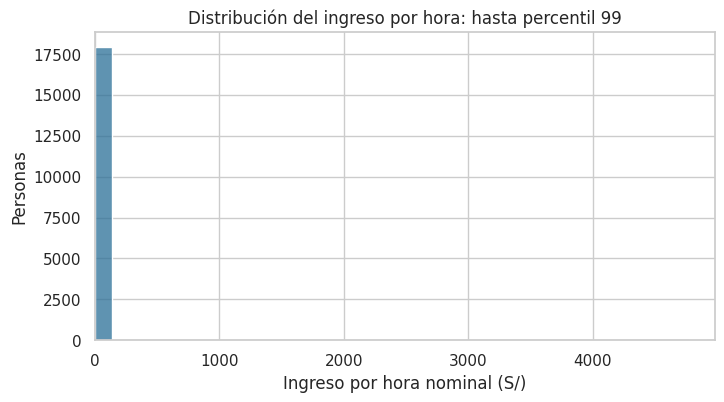

In [32]:
# Recortamos solo la visualización en el percentil 99; no eliminamos esas filas de la base.
limite_grafico = muestra['ingreso_hora_nominal'].quantile(0.99)

plt.figure(figsize=(8, 4))
# Filtramos los datos dentro de la función para que los bins se calculen correctamente
sns.histplot(data=muestra[muestra['ingreso_hora_nominal'] <= limite_grafico], x='ingreso_hora_nominal', bins=35, color='#2a6f97')
plt.xlim(0, limite_grafico)
plt.xlabel('Ingreso por hora nominal (S/)')
plt.ylabel('Personas')
plt.title('Distribución del ingreso por hora: hasta percentil 99')
plt.show()

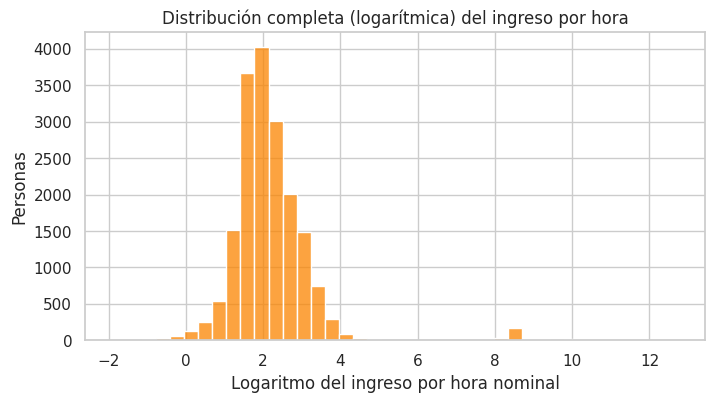

In [33]:
plt.figure(figsize=(8, 4))
# Usamos el logaritmo del ingreso para ver toda la distribución sin recortar la base
sns.histplot(data=muestra, x='log_ingreso_hora', bins=40, color='#fb8500')
plt.xlabel('Logaritmo del ingreso por hora nominal')
plt.ylabel('Personas')
plt.title('Distribución completa (logarítmica) del ingreso por hora')
plt.show()

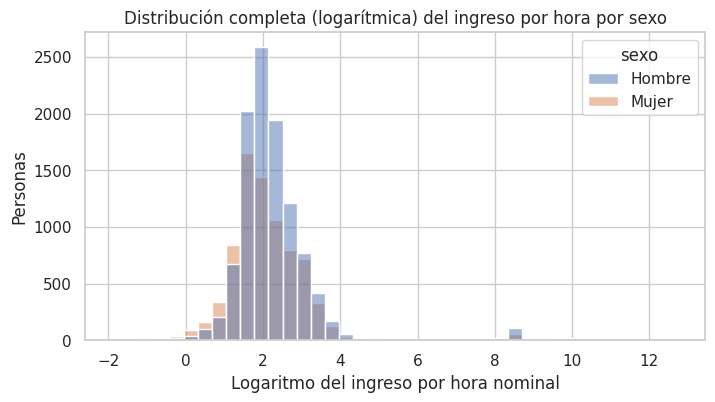

In [35]:
plt.figure(figsize=(8, 4))
# Usamos hue='sexo' para sobreponer las distribuciones de hombres y mujeres
sns.histplot(data=muestra, x='log_ingreso_hora', hue='sexo', bins=40, alpha=0.5)
plt.xlabel('Logaritmo del ingreso por hora nominal')
plt.ylabel('Personas')
plt.title('Distribución completa (logarítmica) del ingreso por hora por sexo')
plt.show()

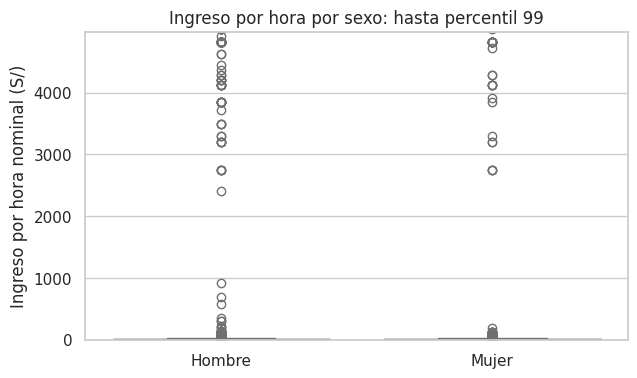

In [34]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=muestra, x='sexo', y='ingreso_hora_nominal', color='#8ecae6')
plt.ylim(0, limite_grafico)
plt.xlabel('')
plt.ylabel('Ingreso por hora nominal (S/)')
plt.title('Ingreso por hora por sexo: hasta percentil 99')
plt.show()


# ✅ Cierre

Hoy pasamos de una operación con cuatro números a una tabla integrada y verificable. Ya tenemos ingredientes descriptivos de una ecuación de Mincer: educación aproximada, experiencia potencial, sexo, área, tamaño del hogar e ingreso por hora.

**Para discutir:**

1. ¿Qué filas se excluyeron al definir la muestra y por qué?
2. ¿Por qué `tamano_hogar` se une con cuatro claves y no con `codperso`?
3. ¿Por qué estos resultados describen asociaciones y no prueban un efecto causal de la educación?

En la sesión de Codex retomaremos esta base para auditar decisiones, mejorar código y estimar una regresión con una interpretación responsable.
